<a href="https://colab.research.google.com/github/shachi-i/Celestial-Intelligence/blob/main/pulsar_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv("HTRU_2.csv")

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17897 entries, 0 to 17896
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   140.5625      17897 non-null  float64
 1   55.68378214   17897 non-null  float64
 2   -0.234571412  17897 non-null  float64
 3   -0.699648398  17897 non-null  float64
 4   3.199832776   17897 non-null  float64
 5   19.11042633   17897 non-null  float64
 6   7.975531794   17897 non-null  float64
 7   74.24222492   17897 non-null  float64
 8   0             17897 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB
None


In [ ]:
print(df.describe())

           140.5625   55.68378214  -0.234571412  -0.699648398   3.199832776  \
count  17897.000000  17897.000000  17897.000000  17897.000000  17897.000000   
mean     111.078321     46.549021      0.477897      1.770417     12.614926   
std       25.652705      6.843040      1.064056      6.168058     29.473637   
min        5.812500     24.772042     -1.876011     -1.791886      0.213211   
25%      100.929688     42.375426      0.027108     -0.188528      1.923077   
50%      115.078125     46.946435      0.223241      0.198736      2.801839   
75%      127.085938     51.022887      0.473349      0.928206      5.464883   
max      192.617188     98.778911      8.069522     68.101622    223.392141   

        19.11042633   7.975531794   74.24222492            0  
count  17897.000000  17897.000000  17897.000000  17897.00000  
mean      26.326918      8.303574    104.859419      0.09158  
std       19.471042      4.506217    106.517270      0.28844  
min        7.370432     -3.139270   

In [ ]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 140.5625        0
55.68378214     0
-0.234571412    0
-0.699648398    0
3.199832776     0
19.11042633     0
7.975531794     0
74.24222492     0
0               0
dtype: int64


In [ ]:
columns = [
    "Mean_IP", "Std_IP", "ExcessKurt_IP", "Skewness_IP",
    "Mean_DM", "Std_DM", "ExcessKurt_DM", "Skewness_DM",
    "Label"
]
df = pd.read_csv("HTRU_2.csv", header=None, names=columns)
print("Missing values:\n", df.isnull().sum())
df.head()

Missing values:
 Mean_IP          0
Std_IP           0
ExcessKurt_IP    0
Skewness_IP      0
Mean_DM          0
Std_DM           0
ExcessKurt_DM    0
Skewness_DM      0
Label            0
dtype: int64


,Mean_IP,Std_IP,ExcessKurt_IP,Skewness_IP,Mean_DM,Std_DM,ExcessKurt_DM,Skewness_DM,Label
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


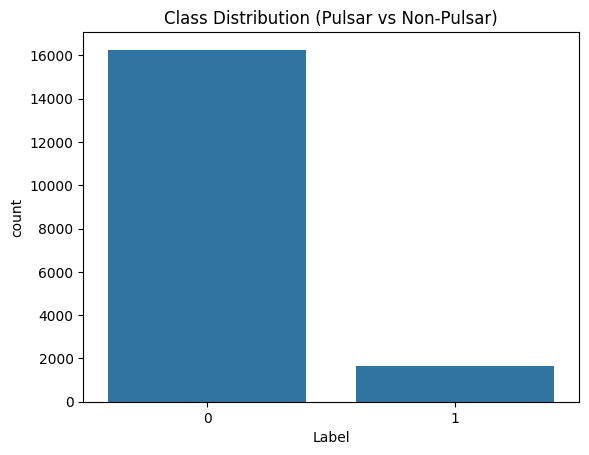

,count
Label,
0,16259
1,1639


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.countplot(x=df["Label"])
plt.title("Class Distribution (Pulsar vs Non-Pulsar)")
plt.show()


df["Label"].value_counts()

In [ ]:
X = df.drop(columns=["Label"])
y = df["Label"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

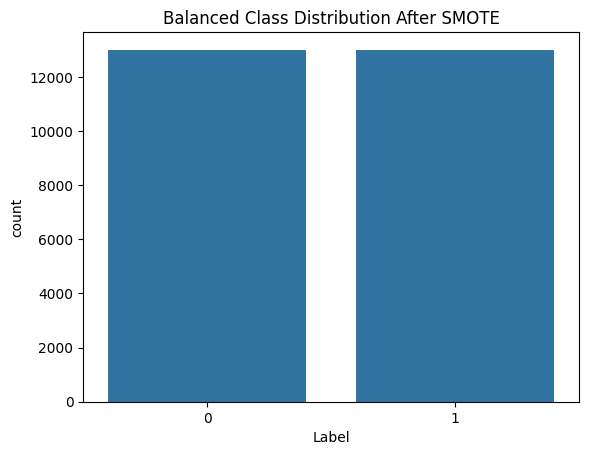

In [ ]:
sns.countplot(x=y_train_resampled)
plt.title("Balanced Class Distribution After SMOTE")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler


In [ ]:
scaler = RobustScaler()
X_train_final = scaler.fit_transform(X_train_resampled)
X_test_final = scaler.transform(X_test)

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train_final, y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report

y_pred = xgb_model.predict(X_test_final)
y_proba = xgb_model.predict_proba(X_test_final)[:, 1]

print("Classification Report (Realistic Performance):")
print(classification_report(y_test, y_pred))
print(f"Realistic ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

Classification Report (Realistic Performance):
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3259
           1       0.77      0.92      0.84       321

    accuracy                           0.97      3580
   macro avg       0.88      0.94      0.91      3580
weighted avg       0.97      0.97      0.97      3580

Realistic ROC-AUC: 0.9775


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix



model_mlp = Sequential([

    Dense(64, activation='relu', input_shape=(X_train_final.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),


    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),


    Dense(16, activation='relu'),


    Dense(1, activation='sigmoid')
])


model_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)


print("Training MLP on balanced data...")
model_mlp.fit(
    X_train_final, y_train_resampled,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


print("\nFinal Performance on Unseen Test Data:")
y_pred_proba = model_mlp.predict(X_test_final)
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_test, y_pred))

Training MLP on balanced data...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


732/732 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9284 - loss: 0.2056 - recall: 0.8915 - val_accuracy: 0.9031 - val_loss: 0.2239 - val_recall: 0.9031
Epoch 2/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9466 - loss: 0.1591 - recall: 0.9149 - val_accuracy: 0.9158 - val_loss: 0.2014 - val_recall: 0.9158
Epoch 3/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9477 - loss: 0.1523 - recall: 0.9187 - val_accuracy: 0.9104 - val_loss: 0.1917 - val_recall: 0.9104
Epoch 4/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9486 - loss: 0.1492 - recall: 0.9194 - val_accuracy: 0.9088 - val_loss: 0.2156 - val_recall: 0.9088
Epoch 5/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9512 - loss: 0.1448 - recall: 0.9231 - val_accuracy: 0.9169 - val_loss: 0.1852 - val_recall: 0.9169
Epoch 6/50
732/732 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9508 - loss: 0.1436 - recall: 0.9226 - val_accuracy: 0.9269 - val_loss: 0.1408 - val_recall: 0.9269
Epoch 7/50
732/